In [287]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import *
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.ensemble import *
from sklearn.pipeline import Pipeline
from category_encoders import TargetEncoder
from imblearn.over_sampling import SMOTE
import joblib

In [288]:
pd.set_option('display.max_columns', None)

In [289]:
data_model = pd.read_csv('data/data_model.csv')
print(data_model.shape)
data_model.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/data_model.csv'

In [275]:
data_model.columns

Index(['id', 'age', 'job', 'education', 'default', 'balance', 'housing',
       'loan', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous',
       'deposit', 'age_group', 'was_contacted_before', 'marital_divorced',
       'marital_married', 'marital_single', 'contact_cellular',
       'contact_telephone', 'contact_unknown_contact', 'poutcome_failure',
       'poutcome_other', 'poutcome_success', 'poutcome_unknown_poutcome',
       'job_target_mean'],
      dtype='object')

## adding more features

In [276]:
data_model['job_edu'] = data_model['job'].astype(str) + "_" + data_model['education'].astype(str)

In [277]:
data_model['job_edu'].unique()

array(['technician_2', 'blue-collar_2', 'student_2', 'admin._2',
       'blue-collar_1', 'management_3', 'entrepreneur_0',
       'self-employed_3', 'technician_3', 'unknown_2', 'services_2',
       'retired_2', 'management_2', 'technician_1', 'housemaid_2',
       'housemaid_1', 'student_0', 'blue-collar_0', 'admin._3',
       'services_1', 'unemployed_2', 'self-employed_2', 'technician_0',
       'retired_1', 'unemployed_3', 'entrepreneur_1', 'admin._1',
       'unemployed_1', 'retired_3', 'entrepreneur_3', 'entrepreneur_2',
       'housemaid_3', 'admin._0', 'unemployed_0', 'blue-collar_3',
       'unknown_0', 'management_1', 'self-employed_1', 'student_3',
       'retired_0', 'unknown_1', 'services_3', 'services_0',
       'housemaid_0', 'management_0', 'student_1', 'unknown_3',
       'self-employed_0'], dtype=object)

## split data to train, val, and test

In [278]:
X = data_model.drop(['id','job_target_mean','job'],axis=1)
y = data_model['deposit']

In [279]:
y.value_counts()

deposit
0    659512
1     90488
Name: count, dtype: int64

In [280]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [281]:
# # pipeline = Pipeline([
# #     ('ctg_encoder', TargetEncoder(cols=['job'])),
# #     ('clf', RandomForestClassifier(random_state=42))
# # ])

# job_encoder = TargetEncoder(cols=['job'])
job_edu_encoder = TargetEncoder(cols=['job_edu'])

# # X_train['job'] = job_encoder.fit_transform(X_train['job'], y_train)
# # X_test['job'] = job_encoder.transform(X_test['job'], y_test)

X_train['job_edu'] = job_edu_encoder.fit_transform(X_train['job_edu'], y_train)
X_test['job_edu'] = job_edu_encoder.transform(X_test['job_edu'], y_test)

## Feature selection

for simplicity, selecting feature using correlation

In [282]:
feature_corr = X_train.corr()['deposit'].sort_values(ascending=False)

In [283]:
feature_corr

deposit                      1.000000
duration                     0.518732
poutcome_success             0.307288
job_edu                      0.171296
was_contacted_before         0.169158
contact_cellular             0.150578
balance                      0.122649
previous                     0.122193
marital_single               0.090861
pdays                        0.088814
education                    0.071781
poutcome_other               0.020693
age_group                    0.015776
contact_telephone            0.010390
age                          0.010169
poutcome_failure             0.008792
month                       -0.001830
marital_divorced            -0.009065
default                     -0.029975
day                         -0.049770
campaign                    -0.076419
marital_married             -0.077403
loan                        -0.081638
housing                     -0.153479
contact_unknown_contact     -0.160104
poutcome_unknown_poutcome   -0.169224
Name: deposi

In [284]:
selected_feature = list(feature_corr[(feature_corr>=0.1) & (feature_corr>=-0.1)].index)
selected_feature = selected_feature[1:]
selected_feature

['duration',
 'poutcome_success',
 'job_edu',
 'was_contacted_before',
 'contact_cellular',
 'balance',
 'previous']

## Use regular model

In [206]:
X_train = X_train.drop(['deposit'],axis=1)
X_test = X_test.drop(['deposit'],axis=1)

### mix sampling

In [207]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
X_train = pd.DataFrame(X_train_res, columns=X_train.columns)
y_train = pd.Series(y_train_res, name=y_train.name)

In [208]:
y_train.value_counts()

deposit
0    527610
1    527610
Name: count, dtype: int64

**with selected features**

In [ ]:
rf = RandomForestClassifier(random_state=42)
adaboost = AdaBoostClassifier(random_state=42)
gboost = GradientBoostingClassifier(random_state=42)
clf = {'Random Forest':rf, 'AdaBoost':adaboost, 'Gradient Boosting': gboost}

for i in clf.keys():
    print(f'Model: {i}')
    clf[i].fit(X_train[selected_feature], y_train)
    y_pred = clf[i].predict(X_test[selected_feature])
    print(classification_report(y_test, y_pred))

Model: Random Forest
              precision    recall  f1-score   support

           0       0.95      0.93      0.94    131902
           1       0.56      0.67      0.61     18098

    accuracy                           0.90    150000
   macro avg       0.76      0.80      0.78    150000
weighted avg       0.91      0.90      0.90    150000

Model: AdaBoost
              precision    recall  f1-score   support

           0       0.98      0.84      0.90    131902
           1       0.42      0.87      0.57     18098

    accuracy                           0.84    150000
   macro avg       0.70      0.85      0.74    150000
weighted avg       0.91      0.84      0.86    150000

Model: Gradient Boosting
              precision    recall  f1-score   support

           0       0.98      0.87      0.92    131902
           1       0.47      0.85      0.60     18098

    accuracy                           0.86    150000
   macro avg       0.72      0.86      0.76    150000
weighted avg

[[110507  21395]
 [  2392  15706]]
              precision    recall  f1-score   support

           0       0.98      0.84      0.90    131902
           1       0.42      0.87      0.57     18098

    accuracy                           0.84    150000
   macro avg       0.70      0.85      0.74    150000
weighted avg       0.91      0.84      0.86    150000



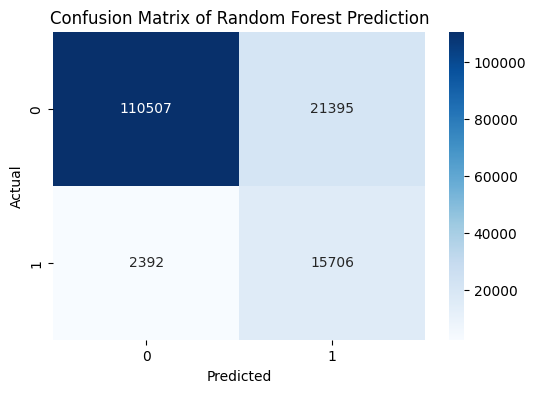

In [244]:
adaboost.fit(X_train[selected_feature], y_train)
y_pred = adaboost.predict(X_test[selected_feature])
y_proba = adaboost.predict_proba(X_test[selected_feature])[:, 1]
cm = confusion_matrix(y_test, y_pred)
labels = list(data_model['deposit'].unique())
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix of Random Forest Prediction")
plt.show()

**saving best model**

decided to choose AdaBoost because the recall between class 0 (not subscribe) and 1 (subscribe) are quite balanced and recall for class 1 is higher

In [285]:
model_file = 'adaboost_trained.pkl'
feature_file = 'selected_feature.pkl'
job_edu_encoder_file = 'job_edu_encoder.pkl'
joblib.dump(adaboost, model_file)
joblib.dump(selected_feature, feature_file)
joblib.dump(job_edu_encoder, job_edu_encoder_file)

['job_edu_encoder.pkl']

In [286]:
selected_feature

['duration',
 'poutcome_success',
 'job_edu',
 'was_contacted_before',
 'contact_cellular',
 'balance',
 'previous']

**with all features**

In [210]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
adaboost = AdaBoostClassifier(random_state=42)
gboost = GradientBoostingClassifier(random_state=42)
clf = {'Random Forest':rf, 'AdaBoost':adaboost, 'Gradient Boosting': gboost}

for i in clf.keys():
    print(f'Model: {i}')
    clf[i].fit(X_train, y_train)
    y_pred = clf[i].predict(X_test)
    print(classification_report(y_test, y_pred))

Model: Random Forest
              precision    recall  f1-score   support

           0       0.96      0.96      0.96    131902
           1       0.69      0.71      0.70     18098

    accuracy                           0.93    150000
   macro avg       0.82      0.83      0.83    150000
weighted avg       0.93      0.93      0.93    150000

Model: AdaBoost
              precision    recall  f1-score   support

           0       0.97      0.90      0.93    131902
           1       0.51      0.77      0.61     18098

    accuracy                           0.88    150000
   macro avg       0.74      0.84      0.77    150000
weighted avg       0.91      0.88      0.89    150000

Model: Gradient Boosting
              precision    recall  f1-score   support

           0       0.97      0.93      0.95    131902
           1       0.59      0.78      0.67     18098

    accuracy                           0.91    150000
   macro avg       0.78      0.85      0.81    150000
weighted avg

## Use cross validation

### use stratifiedkfold for training set only

using this approach is faster (split the data first, then perform gridsearchcv with stratifiedkfold)

In [33]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# scores = cross_val_score(RandomForestClassifier(random_state=42), X_train, y_train, cv=cv, scoring='precision')
# print("Mean CV Accuracy:", scores.mean())

In [58]:
def bestRFClassifier(X, y):
    param_grid = {
        'max_depth': [3, 4, 5, 6, 7, 8]
    }

    grid_search = GridSearchCV(
        estimator=RandomForestClassifier(random_state=42),
        param_grid=param_grid,
        cv=skf,
        scoring='recall',
        return_train_score=True,
    )

    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    best_test_score_rf = grid_search.score(X_test, y_test)
    best_max_depth = grid_search.best_params_['max_depth']
    best_cv_score_rf = grid_search.best_score_

    return best_test_score_rf, best_max_depth, best_cv_score_rf, best_model, best_model, X_train, y_train, y_test, y_pred

best_test_score_rf, best_max_depth, best_cv_score_rf, best_model, best_model, X_train, y_train, y_test, y_pred = bestRFClassifier(X_train, y_train)


[[130773   1129]
 [ 12730   5368]]
              precision    recall  f1-score   support

           0       0.91      0.99      0.95    131902
           1       0.83      0.30      0.44     18098

    accuracy                           0.91    150000
   macro avg       0.87      0.64      0.69    150000
weighted avg       0.90      0.91      0.89    150000



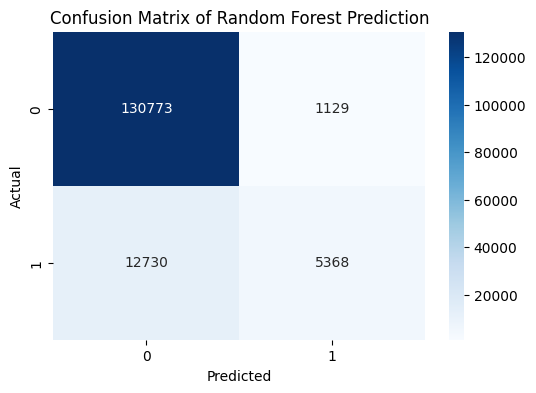

In [31]:
cm = confusion_matrix(y_test, y_pred)
labels = list(data_model['deposit'].unique())
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix of Random Forest Prediction")
plt.show()

this approach (using skf.split, gridsearch every iteration) is taking way longer

In [12]:
# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
# rf = RandomForestClassifier(random_state=42)
# accs, precs, recs = [], [], []
# for train_index, test_index in skf.split(X_train, y_train):
#     x_train_fold = X_train.iloc[train_index]
#     x_test_fold  = X_train.iloc[test_index]
#     y_train_fold = y_train.iloc[train_index]
#     y_test_fold  = y_train.iloc[test_index]

#     param_grid = {
#         'max_depth': [3, 4, 5, 6, 7, 8]
#     }

#     grid_search = GridSearchCV(
#         estimator=rf,
#         param_grid=param_grid,
#         cv=skf,
#         scoring='recall',
#         return_train_score=True,
#     )

#     grid_search.fit(x_train_fold, y_train_fold)
#     best_model = grid_search.best_estimator_
#     y_pred = best_model.predict(x_test_fold)
    
#     acc = accuracy_score(y_test_fold, y_pred)
#     prec = precision_score(y_test_fold, y_pred)
#     rec = recall_score(y_test_fold, y_pred)
#     accs.append(acc)
#     precs.append(prec)
#     recs.append(rec)
#     print(f'Accuracy: {acc}, Precision: {prec}, Recall: {rec}')

# print(f'Mean Accuracy: {np.mean(accs)}, Mean Precision: {np.mean(precs)}, Mean Recall: {np.mean(recs)}')

## Model explainability

In [225]:
%pip install shap

  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.9/554.9 kB 12.2 MB/s eta 0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [shap]2/3 [shap]

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [239]:
# get importance
importance = adaboost.feature_importances_

feat_imp = pd.DataFrame({
    "feature": X_train[selected_feature].columns,
    "importance": importance
}).sort_values("importance", ascending=False)

feat_imp

,feature,importance
0,duration,0.452935
2,job_edu,0.365720
1,poutcome_success,0.063592
5,balance,0.062303
6,previous,0.032468
4,contact_cellular,0.022982
3,was_contacted_before,0.000000


<Axes: xlabel='importance', ylabel='feature'>

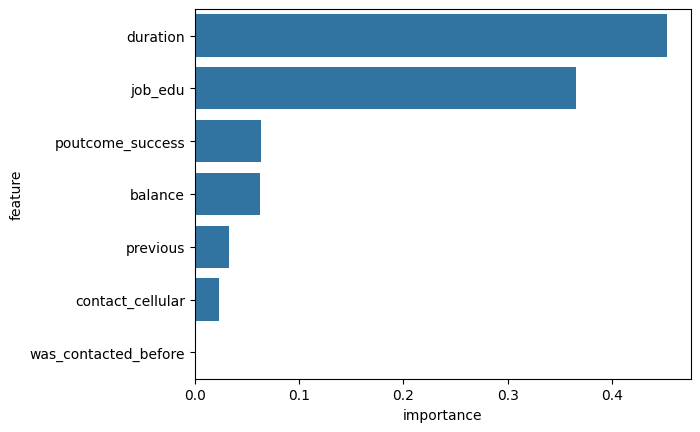

In [243]:
sns.barplot(data=feat_imp, y='feature', x='importance', orient='h')